In [1]:
import numpy as np
import matplotlib.pyplot as plt
import json

In [2]:
## simulation parameters
# distance
d_list = range(3,9,2)
# number of rounds
r_list = range(1,11)
# number of same jobs
job_number = 100

# Load json data

In [4]:
# fraction of accepted shots
Acceptance = np.zeros((len(d_list),len(r_list)))
# fraction of accepted shots uncertainty
Acceptance_u = np.zeros((len(d_list),len(r_list)))
# fraction of failed shots
Error = np.zeros((len(d_list),len(r_list)))
# fraction of failed shots uncertainty
Error_u = np.zeros((len(d_list),len(r_list)))

for index_d, d in enumerate(d_list):
    for index_r, r in enumerate(r_list):
        nb_accepted = 0
        nb_fail = 0
        batch_size = 0
        
        for index in range(job_number):
            result = json.load(open(f'./Results/result_{d}_{r}_{index}.json', 'r'))

            batch_size += result['batch_size']
            nb_fail += result['accepted&fail']
            nb_accepted += result['accepted']
                                       
        Acceptance[index_d,index_r] = nb_accepted/batch_size
        Acceptance_u[index_d,index_r] = np.sqrt(nb_accepted/batch_size*(1-nb_accepted/batch_size)/batch_size)
        
        if nb_accepted != 0:
            Error[index_d,index_r] = nb_fail/nb_accepted
            Error_u[index_d,index_r] = np.sqrt(nb_fail/nb_accepted*(1-nb_fail/nb_accepted)/nb_accepted)
        else:
            Error[index_d,index_r] = np.nan
            Error_u[index_d,index_r] = np.nan

# Acceptance

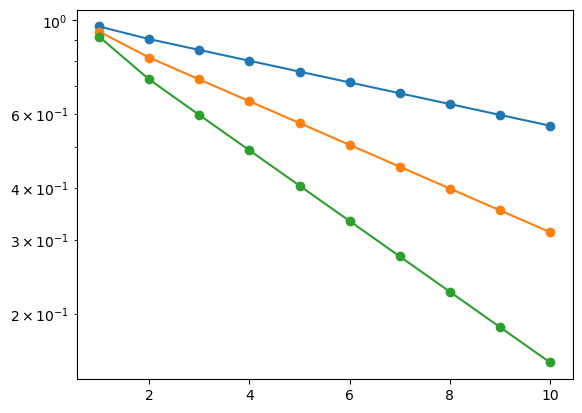

In [4]:
for index_d, d in enumerate(d_list):
    plt.plot(r_list,Acceptance[index_d],'-o')
    plt.fill_between(r_list,Acceptance[index_d] - 1.96*Acceptance_u[index_d],Acceptance[index_d] + 1.96*Acceptance_u[index_d],alpha = 0.25)
        
plt.yscale('log')

In [5]:
np.set_printoptions(linewidth=np.inf)
Acceptance

array([[0.96757613, 0.90286674, 0.85085125, 0.80188342, 0.75568586, 0.71220405, 0.67121737, 0.63258503, 0.59616374, 0.56185076],
       [0.94088041, 0.81617128, 0.72400817, 0.64245557, 0.57006846, 0.50584415, 0.44885082, 0.39828763, 0.35341622, 0.31358651],
       [0.91490541, 0.72381061, 0.5958787 , 0.490984  , 0.40453535, 0.33328083, 0.27462362, 0.22624704, 0.18642402, 0.15360481]])

In [11]:
print("mean number of rounds")
print(5/Acceptance[2][4])

mean number of rounds
12.359859249976896


# Logical error

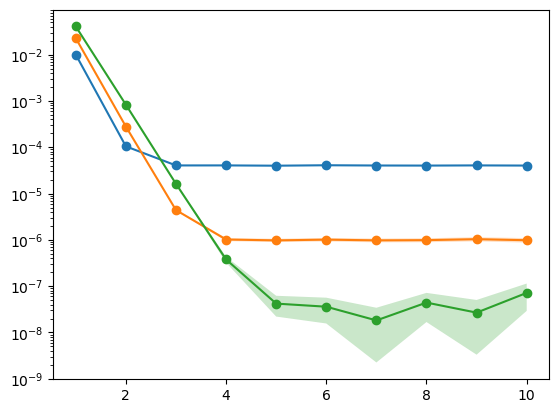

In [12]:
for index_d, d in enumerate(d_list):
    plt.plot(r_list,Error[index_d],'-o')
    plt.fill_between(r_list,Error[index_d] - 1.96*Error_u[index_d],Error[index_d] + 1.96*Error_u[index_d],alpha = 0.25)
        
plt.yscale('log')

In [13]:
Error

array([[1.00095555e-02, 1.04654426e-04, 4.05135445e-05, 4.05869472e-05, 4.00020717e-05, 4.08955834e-05, 4.03893005e-05, 4.02270029e-05, 4.05895201e-05, 4.02615811e-05],
       [2.27015822e-02, 2.79882428e-04, 4.39221561e-06, 1.01796922e-06, 9.75321447e-07, 1.01216946e-06, 9.75825331e-07, 9.86724089e-07, 1.03560612e-06, 9.82185120e-07],
       [4.06430684e-02, 8.30512834e-04, 1.62147094e-05, 3.76794360e-07, 4.20235214e-08, 3.60056710e-08, 1.82067370e-08, 4.41994727e-08, 2.68205779e-08, 7.16123399e-08]])